# LLaVA-7B QLoRA 미니 데모 

LLaVA-1.5-7B(`llava-hf/llava-1.5-7b-hf`)를 **4bit QLoRA**로 소량 데이터만 학습하는 체험용 노트북입니다.

| 항목 | 설정 |
|------|------|
| GPU | RTX 3060 12GB 기준 |
| 학습 샘플 | 64개 (스트리밍으로 일부만 다운로드) |
| 예상 학습 시간 | 약 3~5분 (모델 최초 다운로드 제외) |
| 목적 | 파이프라인 체험 (실용 품질 파인튜닝 아님) |

**흐름:** 환경 설정 → 소량 데이터 로드 → QLoRA 학습 → LoRA 어댑터 추론 테스트

> 이전 노트북: `04_llava_example.ipynb` (추론 전용)  
> 논문: [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485)
<br>
<br>

**모델 정밀도 비교**

| 구분               | FP32   | FP16   | INT8 (8bit) | INT4 (4bit) |
| ---------------- | ------ | ------ | ----------- | ----------- |
| 비트 수             | 32bit  | 16bit  | 8bit        | 4bit        |
| 메모리 사용량          | 100%   | 50%    | 25%         | 12.5%       |
| LLaVA-7B 크기      | 약 28GB | 약 14GB | 약 7GB       | 약 3.5GB     |
| RTX 3060 12GB 로딩 | 불가     | 거의 불가  | 가능          | 매우 여유       |
| 추론 속도            | 기준     | 빠름     | 더 빠름        | 비슷하거나 더 빠름  |
| 정확도              | 최고     | 거의 동일  | 약간 감소       | 소폭 감소       |
| 학습 가능 여부         | 불가     | 거의 불가  | 제한적         | 가능(QLoRA)   |
| 강의 실습 적합성        | 낮음     | 낮음     | 보통          | 매우 높음       |


## 1. 환경 설정

```bash
pip install -r requirements.txt
```

추가 패키지: `trl`, `peft`, `bitsandbytes`, `datasets`

> **Windows**: `bitsandbytes>=0.43` 이상 필요. CUDA GPU가 없으면 QLoRA 학습은 불가합니다.

In [1]:
# QLoRA 학습·추론에 필요한 추가 패키지 설치
# - trl      : SFTTrainer (지도학습 파인튜닝)
# - peft     : LoRA 어댑터
# - bitsandbytes : 4bit 양자화 (QLoRA)
# - datasets : Hugging Face 데이터셋 로드
%pip install -q "trl>=0.9.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "datasets>=2.18.0"



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gc
import inspect
import time
from pathlib import Path

import torch
from datasets import Dataset, load_dataset
from peft import LoraConfig, prepare_model_for_kbit_training
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    LlavaForConditionalGeneration,
)
from trl import SFTConfig, SFTTrainer

# ─────────────────────────────────────────────
# 하이퍼파라미터 (RTX 3060 12GB · 20분 이하 목표)
# ─────────────────────────────────────────────

# Hugging Face 모델·데이터셋 ID
MODEL_ID = "llava-hf/llava-1.5-7b-hf"          # 베이스 VLM (7B)
DATASET_ID = "HuggingFaceH4/llava-instruct-mix-vsft"  # 이미지+대화 SFT 데이터
OUTPUT_DIR = "./llava-7b-qlora-mini"           # LoRA 어댑터 저장 경로

# 학습 규모 — 늘리면 품질↑, 시간·VRAM↑
MAX_SAMPLES = 64          # 사용할 train 샘플 수 (전체 25만+ 중 일부만)
MAX_TEXT_CHARS = 400      # 대화 텍스트 최대 글자 수 (이미지 토큰은 별도 ~576개)
NUM_EPOCHS = 1            # 데이터를 몇 번 반복 학습할지
BATCH_SIZE = 1            # GPU에 한 번에 올리는 샘플 수 (12GB면 1 권장)
GRAD_ACCUM = 4            # N 스텝마다 역전파 → 유효 배치 = 1 × 4 = 4

# LoRA 설정 — rank가 클수록 표현력↑, VRAM·시간↑
LORA_R = 8                # LoRA 저랭크 차원
LORA_ALPHA = 16           # LoRA 스케일 (보통 r의 2배)
LEARNING_RATE = 2e-4        # LoRA 학습률

# 연산 환경
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16  # RTX 3060: fp16 (bf16 AMP 충돌 방지)

if device != "cuda":
    raise RuntimeError("CUDA GPU가 필요합니다. QLoRA 학습은 CPU에서 실행할 수 없습니다.")

# 학습 전 GPU 정보 출력
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"학습 샘플: {MAX_SAMPLES} | max_text_chars: {MAX_TEXT_CHARS}")
print(f"예상 optimizer 스텝: {MAX_SAMPLES // (BATCH_SIZE * GRAD_ACCUM)} (1 epoch)")


GPU: NVIDIA GeForce RTX 3060
VRAM: 12.0 GB
학습 샘플: 64 | max_text_chars: 400
예상 optimizer 스텝: 16 (1 epoch)


## 2. 소량 데이터셋 로드

`HuggingFaceH4/llava-instruct-mix-vsft` 전체(약 198GB)를 받지 않도록 **스트리밍**으로 앞부분만 가져옵니다.

In [3]:
def load_mini_dataset(dataset_id: str, max_samples: int) -> Dataset:
    """스트리밍으로 앞에서 max_samples개만 수집.

    llava-instruct-mix-vsft 전체는 약 198GB이므로,
    streaming=True로 필요한 만큼만 네트워크에서 받아 OOM·시간을 줄입니다.

    각 샘플 구조:
      - messages: [{role, content:[{type,text/image}, ...]}, ...]
      - images  : [PIL.Image, ...]
    """
    stream = load_dataset(dataset_id, split="train", streaming=True)
    samples = []
    for i, row in enumerate(stream):
        samples.append(row)
        if i + 1 >= max_samples:
            break
    return Dataset.from_list(samples)


print(f"데이터셋 로드 중 (최대 {MAX_SAMPLES}개)...")
t0 = time.time()
train_dataset = load_mini_dataset(DATASET_ID, MAX_SAMPLES)
print(f"로드 완료: {len(train_dataset)}개 ({time.time() - t0:.1f}초)")
print(f"컬럼: {train_dataset.column_names}")
# 첫 샘플 user 메시지 일부 확인 (데이터 형식 검증용)
print(f"메시지 예시 (user): {train_dataset[0]['messages'][1]['content'][0]}")
# 약 3.5분 소요


데이터셋 로드 중 (최대 64개)...


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

로드 완료: 64개 (10.2초)
컬럼: ['messages', 'images']
메시지 예시 (user): {'index': None, 'text': 'Donna Eden', 'type': 'text'}


## 3. QLoRA 모델 로드
https://huggingface.co/llava-hf/llava-1.5-7b-hf/tree/main

- **4bit 양자화**로 VRAM 절약 (~8~10GB)
- **비전 타워·projector 동결** → LLM LoRA만 학습
- `q_proj`, `v_proj`에만 LoRA 적용 (메모리 최소화)
<br>
Q = Quantized (4bit 양자화)
<br>
LoRA = Low-Rank Adaptation,작은 저랭크 행렬만 학습

In [4]:
def clear_gpu():
    """Python GC + CUDA 캐시 비우기."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # 비동기 연산 완료 대기


def release_models(*names):
    """노트북 재실행 시 GPU에 남은 모델 변수를 안전하게 해제.

    del만 하면 참조가 남을 수 있어, 존재하는 이름만 삭제 후 clear_gpu() 호출.
    """
    g = globals()
    for name in names:
        if name in g:
            del g[name]
    clear_gpu()


def freeze_vision_modules(model):
    """CLIP 비전 타워·멀티모달 projector 가중치 동결.

    QLoRA는 LLM 쪽 LoRA만 학습합니다. 비전 모듈까지 학습하면 VRAM·시간이 크게 늘어납니다.
    """
    for name, param in model.named_parameters():
        if "vision_tower" in name or "multi_modal_projector" in name:
            param.requires_grad = False


# ── 4bit 양자화 설정 (QLoRA 핵심) ──
# 베이스 7B 가중치를 4bit로 올려 VRAM을 ~8~10GB 수준으로 줄입니다.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                         # 4bit 가중치 로드
    bnb_4bit_quant_type="nf4",                 # NormalFloat4 양자화
    bnb_4bit_compute_dtype=compute_dtype,      # 연산 시 캐스팅 dtype
    bnb_4bit_use_double_quant=True,            # 이중 양자화로 추가 메모리 절약
)

print(f"모델 로드 중: {MODEL_ID} (4bit QLoRA)...")
# processor = 토크나이저 + 이미지 전처리기 통합
processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "right"     # 배치 패딩을 오른쪽에 추가
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# 베이스 LLaVA 로드 (학습 시 LoRA가 이 위에 붙음)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",       # GPU에 자동 배치
    torch_dtype=compute_dtype,
)
# k-bit 학습 준비: gradient checkpointing 등 활성화
model = prepare_model_for_kbit_training(
    model, use_gradient_checkpointing=True
)
freeze_vision_modules(model)

# LoRA 어댑터 설정 — attention의 q_proj, v_proj만 미세조정
peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "v_proj"],  # 메모리 최소화용 타깃
    task_type="CAUSAL_LM",
)

allocated = torch.cuda.memory_allocated() / 1024**3
print(f"모델 로드 완료 | GPU 할당: {allocated:.2f} GB")
# PC에서 다운로드 약 22분 소요 (약 14GB 크기)

모델 로드 중: llava-hf/llava-1.5-7b-hf (4bit QLoRA)...


W0613 19:12:24.010000 22580 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


모델 로드 완료 | GPU 할당: 4.28 GB


## 4. 데이터 콜레이터 & 학습 설정

In [5]:
def trim_messages(messages, max_chars: int):
    """대화 messages에서 텍스트만 글자 수로 자름.

    VLM은 processor truncation(max_length)을 쓰면
    이미지 토큰(~576개)이 input_ids에서 잘려 오류가 납니다.
    → 텍스트만 미리 자르고, processor에는 truncation을 쓰지 않습니다.
    """
    trimmed = []
    for msg in messages:
        content = []
        for item in msg["content"]:
            if item.get("type") == "text" and len(item["text"]) > max_chars:
                content.append({"type": "text", "text": item["text"][:max_chars]})
            else:
                content.append(item)  # image placeholder 등은 그대로 유지
        trimmed.append({"role": msg["role"], "content": content})
    return trimmed


def collate_fn(examples):
    """DataLoader가 호출하는 배치 전처리 함수.

    1) messages → chat template 문자열
    2) images  → RGB PIL 리스트
    3) processor로 텐서화
    4) labels에서 pad·image 토큰 마스킹 (-100 = loss 제외)
    """
    texts = [
        processor.apply_chat_template(
            trim_messages(ex["messages"], MAX_TEXT_CHARS),
            tokenize=False,
            add_generation_prompt=False,  # 학습: assistant 답까지 포함
        ).strip()
        for ex in examples
    ]
    # LLaVA 배치 형식: 샘플마다 이미지 리스트
    images = [[img.convert("RGB") for img in ex["images"]] for ex in examples]

    # truncation 사용 금지 — 이미지 토큰 개수와 input_ids 불일치 방지
    batch = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    # Causal LM 학습용 labels (input_ids 복사)
    labels = batch["input_ids"].clone()
    # 패딩 토큰은 loss 계산에서 제외
    labels[labels == processor.tokenizer.pad_token_id] = -100

    # <image> 플레이스홀더 토큰도 loss에서 제외 (이미지는 vision tower가 처리)
    image_token = getattr(processor, "image_token", "<image>")
    image_token_id = processor.tokenizer.convert_tokens_to_ids(image_token)
    if image_token_id is not None:
        labels[labels == image_token_id] = -100

    batch["labels"] = labels
    return batch


# ── SFTTrainer 학습 인자 ──
sft_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True,               # activation 재계산으로 VRAM 절약
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",                  # 8bit 옵티마이저 (VRAM 절약)
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=4,
    save_strategy="no",                        # 미니 데모: 중간 체크포인트 생략
    eval_strategy="no",
    fp16=False,
    bf16=False,  # QLoRA+PEFT: fp16 AMP와 bf16 gradient dtype 충돌 방지
    max_grad_norm=0.3,                         # gradient clipping
    report_to="none",                          # wandb 등 비활성화
    remove_unused_columns=False,               # VLM: images 컬럼 유지 필수
    dataset_kwargs={"skip_prepare_dataset": True},  # collate_fn이 직접 전처리
    dataloader_num_workers=0,                  # Windows 노트북: 0 권장
    max_length=None,  # VLM: truncation 시 이미지 토큰 불일치 → None 필수
    assistant_only_loss=False,  # TRL: VLM은 assistant_only_loss 미지원
)

training_args = SFTConfig(**sft_kwargs)
print("학습 설정 완료")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


학습 설정 완료


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22580\1344374467.py:88: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(**sft_kwargs)


## 5. QLoRA 학습 실행

64샘플 × 1 epoch × batch 1 × grad_accum 4 → **약 16 스텝** (RTX 3060에서 3~5분 예상)

In [6]:
# SFTTrainer에 넘길 인자 묶음
trainer_kwargs = dict(
    model=model,                   # 4bit로 로드된 베이스 + LoRA 적용 예정
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,      # 위에서 정의한 VLM 배치 함수
    peft_config=peft_config,       # Trainer가 LoRA 어댑터를 자동 부착
)

# TRL 버전별 인자명 차이 (신버전: processing_class / 구버전: tokenizer)
if "processing_class" in inspect.signature(SFTTrainer.__init__).parameters:
    trainer_kwargs["processing_class"] = processor
else:
    trainer_kwargs["tokenizer"] = processor.tokenizer

trainer = SFTTrainer(**trainer_kwargs)

print("=" * 50)
print("학습 시작")
train_start = time.time()
train_result = trainer.train()  # 실제 QLoRA 역전파·가중치 업데이트
train_minutes = (time.time() - train_start) / 60

print("=" * 50)
print(f"학습 완료 | 소요 시간: {train_minutes:.1f}분")
print(f"train_loss: {train_result.training_loss:.4f}")
# if train_minutes > 20:
#     print("⚠ 20분 초과 — MAX_SAMPLES를 줄이거나 MAX_TEXT_CHARS를 256으로 낮춰 보세요.")
# else:
#     print("✓ 20분 이하 목표 달성")

# RTX 3060 : 약 3.5분 소요

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


학습 시작


Step,Training Loss
4,3.442179
8,2.470811
12,1.925985
16,1.649605


학습 완료 | 소요 시간: 3.5분
train_loss: 2.3721


In [7]:
# LoRA 어댑터만 저장 (~50MB) — 베이스 7B 전체(13GB)는 저장하지 않음
# 추론 시 Hugging Face에서 베이스 모델을 다시 로드하고 어댑터를 merge/attach 합니다.
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)  # chat template·이미지 전처리 설정
print(f"어댑터 저장: {Path(OUTPUT_DIR).resolve()}")

어댑터 저장: C:\MyCursorLab\07_Vision_Language_Model\llava-7b-qlora-mini


## 6. 학습 후 추론 테스트

저장된 LoRA 어댑터를 로드해 학습 데이터 첫 샘플로 간단히 생성해 봅니다.

> **이 셀만 단독 실행 가능** — `release_models`, `bnb_config`, `processor` 등을 셀 안에서 정의합니다.  
> 재실행 시 이전 `infer_model`이 GPU에 남아 있으면 VRAM 부족으로 로드 실패할 수 있습니다.

로드 전 VRAM: 4.31 GB


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

로드 후 VRAM: 8.12 GB


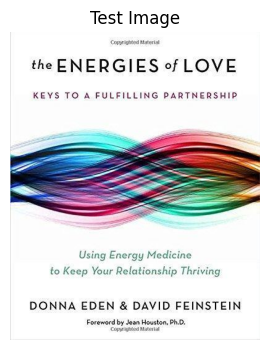

질문: Who wrote this book?

LoRA 모델 답변: Donna Eden


In [9]:
# ═══════════════════════════════════════════════════════════
# 6. 학습 후 추론 테스트 (이 셀만 단독 실행 가능)
# ═══════════════════════════════════════════════════════════
import gc

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import PeftModel
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig, LlavaForConditionalGeneration

# 앞 셀을 실행하지 않았을 때 쓸 기본값 (globals에 있으면 그대로 사용)
MODEL_ID = globals().get("MODEL_ID", "llava-hf/llava-1.5-7b-hf")
OUTPUT_DIR = globals().get("OUTPUT_DIR", "./llava-7b-qlora-mini")
compute_dtype = globals().get("compute_dtype", torch.float16)


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def release_models(*names):
    """재실행 시 이전 infer_model/base_model이 GPU에 남지 않도록 해제."""
    g = globals()
    for name in names:
        if name in g:
            del g[name]
    clear_gpu()


# ── 1) 이전 모델 해제 (재실행 필수) ──
release_models("infer_model", "base_model", "trainer", "model", "inputs", "output_ids")
print(f"로드 전 VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# ── 2) 4bit 베이스 + LoRA 어댑터 로드 ──
if "bnb_config" not in globals():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

# 학습 때 저장한 processor 우선 사용 (chat template 일치)
if "processor" not in globals():
    processor = AutoProcessor.from_pretrained(OUTPUT_DIR)

base_model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
)
# OUTPUT_DIR의 LoRA 가중치를 베이스에 부착
infer_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
infer_model.eval()  # dropout 등 비활성화

print(f"로드 후 VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# ── 3) 테스트용 샘플 1개 준비 ──
if "train_dataset" in globals():
    sample = train_dataset[0]
else:
    # 학습 셀 없이 추론만 할 때: 스트리밍으로 1개만 받기
    DATASET_ID = globals().get("DATASET_ID", "HuggingFaceH4/llava-instruct-mix-vsft")
    sample = next(iter(load_dataset(DATASET_ID, split="train", streaming=True)))

test_image = sample["images"][0].convert("RGB")
# user 역할 메시지에서 텍스트 질문만 추출
user_text = next(
    c["text"]
    for m in sample["messages"]
    if m["role"] == "user"
    for c in m["content"]
    if c.get("type") == "text"
)

# ── 4) 추론 프롬프트 구성 및 생성 ──
messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": user_text}]}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
inputs = processor(text=prompt, images=[test_image], return_tensors="pt").to(infer_model.device)

with torch.inference_mode():
    output_ids = infer_model.generate(**inputs, max_new_tokens=128, do_sample=False)

# ── 5) 결과 디코딩 및 출력 ──
generated = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
if "ASSISTANT:" in generated:
    answer = generated.split("ASSISTANT:")[-1].strip()
else:
    answer = generated.strip()

plt.figure(figsize=(6, 4))
plt.imshow(test_image)
plt.axis("off")
plt.title("Test Image")
plt.show()

print(f"질문: {user_text}")
print(f"LoRA 모델 답변: {answer}")
# RTX 3060 : 약 2분 소요

## 7. 트러블슈팅

| 증상 | 해결 |
|------|------|
| BFloat16 / fp16 오류 | `fp16=False`, `bf16=False` 유지 (QLoRA는 AMP 없이 학습) |
| CUDA OOM | `MAX_TEXT_CHARS=256`, `MAX_SAMPLES=32`, `LORA_R=4` |
| image token mismatch | processor에 `truncation` 사용 금지 (이미지 토큰 ~576개) |
| bitsandbytes 오류 (Windows) | `pip install -U bitsandbytes` 후 커널 재시작 |
| 학습 20분 초과 | `MAX_SAMPLES` 줄이기, `GRAD_ACCUM=2` |
| 추론 재실행 OOM/CPU offload | `release_models()` 후 재로드. 또는 **커널 재시작** |
| `trainer` NameError | `del trainer` 대신 `release_models("trainer", ...)` 사용 |

### 품질 향상 가이드 (시간·VRAM 증가)

이 노트북은 **64샘플·1 epoch·LoRA 2모듈**로 파이프라인 체험에 맞춰져 있습니다. 추론 답변이 학습 데이터와 비슷하거나 짧게 나오는 것은 정상에 가깝습니다. 품질을 조금씩 올리려면 아래를 **한 번에 하나씩** 바꿔 보세요.

| 조정 항목 | 기본값 (데모) | 품질 향상 예시 | 효과 | 주의 |
|-----------|--------------|----------------|------|------|
| `MAX_SAMPLES` | 64 | 256 → 500 → 1000 | 데이터 다양성↑, 과적합↓ | 스트리밍이라 네트워크·로드 시간 증가. 500개 ≈ 수십 분 학습 |
| `NUM_EPOCHS` | 1 | 2~3 | 같은 데이터를 더 반복 학습 | 샘플이 적으면 **과적합**(암기) 위험. 샘플을 늘린 뒤 epoch 올리기 |
| `LORA_R` / `LORA_ALPHA` | 8 / 16 | 16 / 32 | LoRA 표현력↑ | VRAM·학습 시간 증가. OOM 시 `LORA_R=4`로 되돌리기 |
| `target_modules` | `q_proj`, `v_proj` | `k_proj`, `o_proj` 추가 | attention 4개 전부 미세조정 | 모듈당 VRAM·시간 소폭 증가. 더 올리려면 `gate_proj`, `up_proj`, `down_proj`(MLP)도 가능 |
| `MAX_TEXT_CHARS` | 400 | 600~800 | 긴 질문·답변 학습 | 시퀀스 길이↑ → VRAM↑. truncation은 쓰지 말 것 |
| `LEARNING_RATE` | 2e-4 | 1e-4 | 수렴 안정성↑ (느리게 학습) | 너무 낮으면 1 epoch에서 변화 거의 없음 |

**권장 순서 (RTX 3060 12GB 기준)**

1. **`MAX_SAMPLES=256`** — 가장 효과 대비 비용이 좋음 (다양한 이미지·대화 패턴 노출)
2. **`target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]`** — LoRA 범위 확대 (메모리 여유 있을 때)
3. **`NUM_EPOCHS=2`** — 256샘플 이상일 때 시도
4. **`LORA_R=16`** — 위 설정으로도 부족할 때

**기대 수준**

- 64샘플 미니 학습: **특정 스타일·짧은 답** 정도만 반영되는 **체험용** 수준
- 500~1000샘플 + 2 epoch: 캡션·VQA에서 **눈에 띄는 개선** 가능 (여전히 전체 25만+ SFT 대비는 제한적)
- 실용 품질: 도메인 데이터로 **수천~수만 샘플**, 더 넓은 LoRA, 멀티 epoch·검증셋이 일반적

**한계 (TRL + LLaVA)**

- `assistant_only_loss=True`는 VLM에서 **미지원** → user+assistant 전체에 loss가 계산됨
- user 구간 loss를 빼려면 `collate_fn`에서 assistant 시작 위치만 label을 남기는 **수동 마스킹**이 필요 (고급)
- 비전 타워는 동결 상태이므로, **이미지 이해 자체**를 바꾸려면 vision LoRA·전체 파인튜닝 등 별도 설정 필요

**관련 노트북:** `04_llava_example.ipynb` (fp16 전체 모델 추론)